# 02 - NIHSA Flood Record

Processes the NIHSA LGA-level flood history dataset (2013–2023), cleans and standardises the records, and joins them to the 42 selected LGAs.

**Outputs saved to Azure:**
- `ds-aa-nga-flooding/processed/nihsa/floodhistory_2013_2023_sel_lgas.parquet` — Cleaned NIHSA flood event records for selected LGAs

In [115]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [116]:
import pandas as pd

from src.utils import blob
from src.constants import *
import ocha_stratus as stratus
from dotenv import load_dotenv

load_dotenv()

True

In [117]:
adm2 = stratus.codab.load_codab_from_blob("NGA", admin_level=2)

In [118]:
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas.parquet"
)

In [119]:
blob_name = f"{PROJECT_PREFIX}/raw/AA-nigeria_data/NiHSA/LGA_Flood_History 2013-2023.xlsx"
dfs = blob.load_excel_from_blob(blob_name, sheet_name=None)

In [120]:
df_nihsa = (
    pd.concat(dfs.values(), keys=dfs.keys(), names=["Year", "Index"])
    .reset_index()
    .drop(columns="Index")
)
df_nihsa["LGA"] = df_nihsa["LGA"].fillna(df_nihsa["LGAs"])
df_nihsa["State"] = df_nihsa["State"].fillna(df_nihsa["STATE"])
df_nihsa = df_nihsa.drop(columns=["LGAs", "STATE"])
df_nihsa["Flooded"] = df_nihsa["Flooded"].astype(bool)
df_nihsa["Year"] = df_nihsa["Year"].astype(int)
df_nihsa = df_nihsa.dropna()
df_nihsa = df_nihsa[~df_nihsa["LGA"].isin(["Lake chad", "Lagos Lagoon"])]
df_nihsa = df_nihsa[
    df_nihsa["LGA"] != "Kuban"
]  # Not sure which this is assigned to. Only 2023 data.
df_nihsa["LGA"] = df_nihsa["LGA"].replace(
    {
        "Bukuru": "Buruku",
        "Koton-Karfe": "Kogi",
        "Girie": "Girei",
        "Teungo": "Toungo",
        "Borsari": "Bursari",
        "Barde": "Bade",
        "Olamaboro": "Olamabolo",
        "Emuoha": "Emohua",
        "Larmurde": "Lamurde",
        "Makarfi": "Markafi",  # This seems like a case where the cods are wrong
        "kaduna South": "Kaduna South",
    }
)

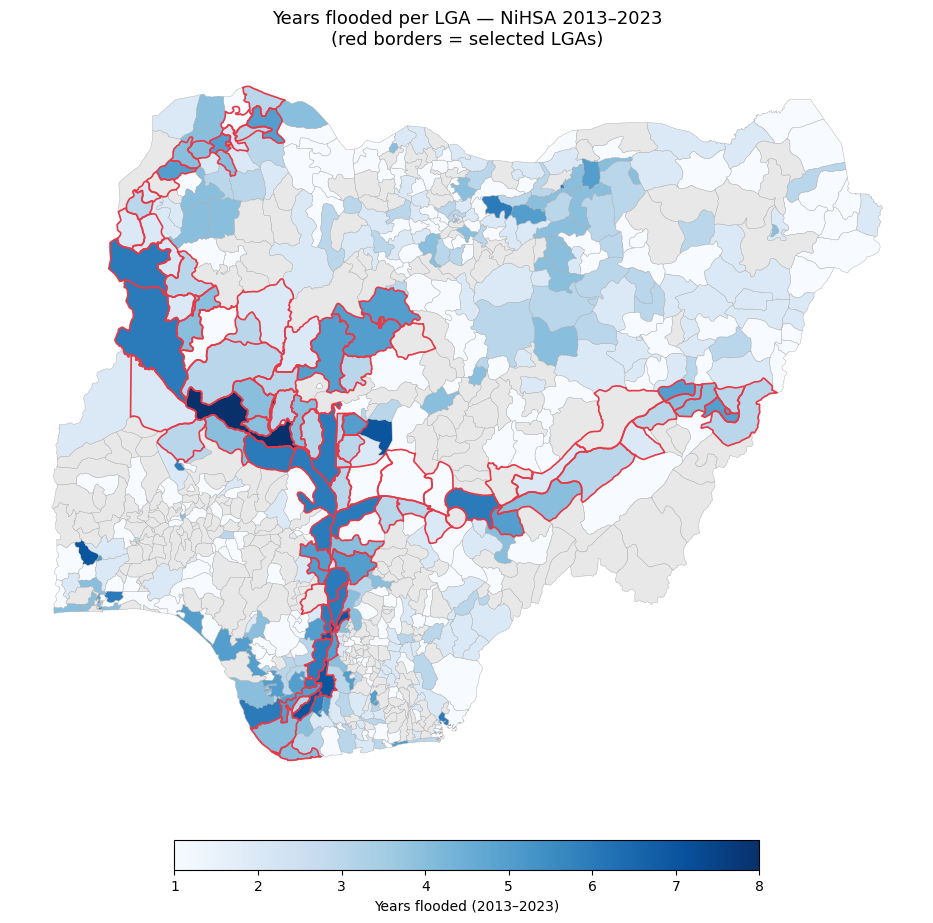

In [121]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Count years flooded per LGA across full dataset (2013–2023)
df_years_flooded = (
    df_nihsa[df_nihsa["Flooded"]]
    .groupby(["State", "LGA"])["Year"]
    .nunique()
    .reset_index()
    .rename(columns={"Year": "years_flooded"})
)

# Join to adm2 by exact state + LGA name match
# Note: LGAs with name mismatches vs CODAB will show as 0
gdf_years = adm2.merge(
    df_years_flooded,
    left_on=["ADM1_EN", "ADM2_EN"],
    right_on=["State", "LGA"],
    how="left",
)
gdf_years["years_flooded"] = gdf_years["years_flooded"].fillna(0).astype(int)

# Use NaN for zero so missing_kwds renders them grey
gdf_years["years_flooded_plot"] = gdf_years["years_flooded"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(12, 10))

gdf_years.plot(
    column="years_flooded_plot",
    cmap="Blues",
    legend=True,
    legend_kwds={
        "label": "Years flooded (2013–2023)",
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.05,
    },
    missing_kwds={"color": "#e8e8e8", "label": "0 years / no data"},
    ax=ax,
    edgecolor="#aaaaaa",
    linewidth=0.3,
)

# Overlay selected LGA borders in red
gdf_lga_sel.plot(
    ax=ax, facecolor="none", edgecolor="#E63946", linewidth=1.2, zorder=3
)

ax.set_title(
    "Years flooded per LGA — NiHSA 2013–2023\n(red borders = selected LGAs)",
    fontsize=13,
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(
    "figures/nihsa_years_flooded_map.png", dpi=200, bbox_inches="tight"
)

In [122]:
df_nihsa = df_nihsa[df_nihsa["State"].isin(list(gdf_lga_sel.ADM1_EN.unique()))]

In [123]:
df_nihsa

,Year,State,LGA,Flooded
17,2013,Adamawa,Demsa,False
18,2013,Adamawa,Fufore,False
19,2013,Adamawa,Ganye,False
20,2013,Adamawa,Girei,False
21,2013,Adamawa,Gombi,False
...,...,...,...,...
8490,2023,Taraba,Lau,True
8491,2023,Taraba,Jalingo,False
8492,2023,Taraba,Wukari,True
8493,2023,Taraba,Donga,False


In [124]:
import pandas as pd
from thefuzz import process

# Example dataframes: df_nihsa and adm2
# df_nihsa['LGA'] should match adm2['ADM2_EN']


def match_LGAs(df_nihsa, adm2, threshold=90):
    # Create an empty dictionary to store the matched values
    matches = {}

    # Iterate over each LGA in df_nihsa
    for lga in df_nihsa["LGA"]:
        # Use thefuzz to find the best match in the 'ADM2_EN' column of adm2
        result = process.extractOne(lga, adm2["ADM2_EN"])

        # Print the result to inspect its structure (for debugging)
        # print(f"Result for '{lga}': {result}")

        # Check if the result is a tuple or dictionary
        if isinstance(result, tuple):
            best_match, score, _ = result
        elif isinstance(result, dict):
            best_match = result.get("string")
            score = result.get("score", 0)
        else:
            best_match, score = None, 0

        # If the score is above the threshold, consider it a match
        if score >= threshold:
            matches[lga] = best_match
        else:
            matches[lga] = None  # No match found

    # Add a new column 'matched_ADM2_EN' to df_nihsa based on the matches
    df_nihsa["matched_ADM2_EN"] = df_nihsa["LGA"].map(matches)

    # Identify LGAs that did not get matched
    unmatched = df_nihsa[df_nihsa["matched_ADM2_EN"].isna()]

    # Provide a report of unmatched entries for manual assignment
    if not unmatched.empty:
        print("The following LGAs were not automatically matched:")
        print(unmatched[["LGA"]])
        print("\nPlease manually assign matches to these LGAs.")

    # Confirm all LGA entries got matched (if you want to raise an error if not)
    if unmatched.shape[0] > 0:
        raise ValueError(
            f"{unmatched.shape[0]} LGAs were not matched. Please check the unmatched list above."
        )

    return df_nihsa


# Run the function with your dataframes
df_nihsa = match_LGAs(df_nihsa, adm2)

In [125]:
df_floodrecord = df_nihsa[
    df_nihsa["matched_ADM2_EN"].isin(gdf_lga_sel.ADM2_EN.unique())
]
df_floodrecord = df_floodrecord.rename(columns={"matched_ADM2_EN": "ADM2_EN"})

In [126]:
assert df_floodrecord.ADM2_EN.nunique() == 97

In [127]:
df_floodrecord = df_floodrecord.merge(adm2[["ADM2_EN", "ADM2_PCODE"]])

In [128]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/nihsa/floodhistory_2013_2023_sel_lgas.parquet"
)
stratus.upload_parquet_to_blob(
    df_floodrecord.drop(columns=["State", "LGA"]), blob_name
)